# Probes de features genômicas — EVO2 7B — v3 (codon usage a partir das CDS reais)

**Correção metodológica do v2.** O `codon_enc` do v2 era ENC de Wright em **frame-0 sobre o genoma inteiro** (proxy, sem anotação de CDS). Aqui o ENC é calculado sobre as **CDS reais** extraídas do gbff (`viral.1.genomic.gbff.gz`), respeitando `location` (join/complement) e `codon_start`.

**Não recalcula embeddings.** Os embeddings (`embeddings_features_evo2_7b_w32768.npz`) são reaproveitados do cache (local ou S3) — sem modelo, sem GPU, sem FP8. Só recomputa o *alvo* `codon_enc` e re-roda a regressão (puro CPU). `host`/`família`/PCA são idênticos ao v2 (mesmos embeddings) e ficam de fora aqui.

In [1]:
# ============================ CONFIG ============================
BUCKET        = "<YOUR_S3_BUCKET>"
MANIFEST_KEY  = "corpus/raw/v1_refseq/composed/composition_manifest.parquet"
FEATURES_KEY  = "corpus/raw/v1_refseq/features/genome_features.parquet"
FASTA_KEY     = "corpus/raw/v1_refseq/fasta/all_genomes.fasta"
GBFF_KEY      = "corpus/raw/v1_refseq/genbank/viral.1.genomic.gbff.gz"
import os
LOCAL_DIR     = os.path.expanduser("~/evo2_probe")   # robusto: home pode ser /home/<USER> ou /home/<USER>

MODEL_NAME    = "evo2_7b"
WINDOW        = 32768
EMB_CACHE     = f"{LOCAL_DIR}/embeddings_features_{MODEL_NAME}_w{WINDOW}.npz"
EMB_CACHE_S3  = "experiments/embed_probes/embeddings/embeddings_features_evo2_7b_w32768.npz"

ENC_CACHE     = f"{LOCAL_DIR}/codon_enc_cds.parquet"
ENC_CACHE_S3  = "experiments/embed_probes/features/codon_enc_cds.parquet"
GBFF_LOCAL    = f"{LOCAL_DIR}/viral.1.genomic.gbff.gz"
SEED          = 42
os.makedirs(LOCAL_DIR, exist_ok=True)
print("config OK ·", MODEL_NAME, "· WINDOW", WINDOW, "· LOCAL_DIR", LOCAL_DIR)

config OK · evo2_7b · WINDOW 32768 · LOCAL_DIR /home/<USER>/evo2_probe


In [2]:
# ============================ SETUP ============================
import sys, subprocess
def pip(*p): subprocess.run([sys.executable,"-m","pip","install","-q",*p], check=False)
pip("scikit-learn","matplotlib","pandas","pyarrow","boto3","biopython")
import numpy as np, pandas as pd, boto3, os
from collections import Counter
s3 = boto3.client("s3","us-east-1")
print("setup OK")

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.3-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 w

setup OK


In [3]:
# ============================ 1. Carregar embeddings do cache (sem modelo) ============================
# Baixa o .npz do S3 se não houver local. Reaproveita os embeddings já computados.
if not os.path.exists(EMB_CACHE):
    print("baixando embeddings do S3:", EMB_CACHE_S3)
    s3.download_file(BUCKET, EMB_CACHE_S3, EMB_CACHE)
d = np.load(EMB_CACHE, allow_pickle=True)
X, accs = d["X"].astype(np.float32), d["accs"].astype(str)
print("embeddings:", X.shape, "| genomas:", len(accs))

baixando embeddings do S3: experiments/embed_probes/embeddings/embeddings_features_evo2_7b_w32768.npz
embeddings: (1200, 4096) | genomas: 1200


In [4]:
# ============================ 2. Metadados do subset (alinhados aos embeddings) ============================
for key in (MANIFEST_KEY, FEATURES_KEY):
    dst = f"{LOCAL_DIR}/{os.path.basename(key)}"
    if not (os.path.exists(dst) and os.path.getsize(dst) > 0): s3.download_file(BUCKET, key, dst)
man  = pd.read_parquet(f"{LOCAL_DIR}/{os.path.basename(MANIFEST_KEY)}")
feat = pd.read_parquet(f"{LOCAL_DIR}/{os.path.basename(FEATURES_KEY)}")
feat_cols = [c for c in ["accession","GC","genome_length","coding_fraction","gene_density",
                         "n_genes","n_CDS","noncoding_bp","mean_intergenic_len","family","host"] if c in feat.columns]
meta = man.merge(feat[feat_cols], on="accession", how="left")
# alinhar EXATAMENTE à ordem dos embeddings (accs)
subset = meta.set_index("accession").reindex(accs).reset_index()
print("subset alinhado:", subset.shape, "| nulos em coding_fraction:", subset["coding_fraction"].isna().sum())

subset alinhado: (1200, 18) | nulos em coding_fraction: 0


In [5]:
# ============================ 3. Carregar FASTA do subset (p/ GC regional e recombinação) ============================
fa = f"{LOCAL_DIR}/{os.path.basename(FASTA_KEY)}"
if not (os.path.exists(fa) and os.path.getsize(fa) > 0): s3.download_file(BUCKET, FASTA_KEY, fa)
wanted = set(accs.tolist()); seqs = {}; acc, buf = None, []
def flush():
    if acc is not None and acc in wanted: seqs[acc] = "".join(buf)
with open(fa) as fh:
    for ln in fh:
        if ln.startswith(">"):
            flush(); acc = ln[1:].split()[0]; buf = []
        else: buf.append(ln.strip())
flush()
print("sequências carregadas:", len(seqs), "de", len(wanted))

sequências carregadas: 1200 de 1200


In [6]:
# ============================ 4. Helpers (ENC de Wright, GC regional, recombinação) ============================
_COMP = str.maketrans("ACGT","TGCA")
def _rc(s): return s.translate(_COMP)[::-1]

_SYN = {
 2:[["TTT","TTC"],["TAT","TAC"],["CAT","CAC"],["CAA","CAG"],["AAT","AAC"],
    ["AAA","AAG"],["GAT","GAC"],["GAA","GAG"],["TGT","TGC"]],
 3:[["ATT","ATC","ATA"]],
 4:[["GTT","GTC","GTA","GTG"],["CCT","CCC","CCA","CCG"],["ACT","ACC","ACA","ACG"],
    ["GCT","GCC","GCA","GCG"],["GGT","GGC","GGA","GGG"]],
 6:[["TTA","TTG","CTT","CTC","CTA","CTG"],
    ["CGT","CGC","CGA","CGG","AGA","AGG"],
    ["TCT","TCC","TCA","TCG","AGT","AGC"]],
}
def enc_from_counter(cc):
    "ENC de Wright a partir de um Counter de códons (já em frame)."
    Fcls = {}
    for deg, fams in _SYN.items():
        Fs = []
        for fam in fams:
            n = sum(cc.get(c,0) for c in fam)
            if n < 2: continue
            p2 = sum((cc.get(c,0)/n)**2 for c in fam)
            F = (n*p2 - 1)/(n - 1)
            if F > 0: Fs.append(F)
        if Fs: Fcls[deg] = sum(Fs)/len(Fs)
    if 2 not in Fcls and 4 not in Fcls: return np.nan
    F2 = Fcls.get(2); F4 = Fcls.get(4)
    if F2 is None: F2 = F4
    if F4 is None: F4 = F2
    F3 = Fcls.get(3, (F2+F4)/2); F6 = Fcls.get(6, F4)
    return float(min(61.0, max(20.0, 2 + 9/F2 + 1/F3 + 5/F4 + 3/F6)))

def codon_enc_genome(seq):
    "ENC frame-0 no genoma inteiro (o PROXY do v2, mantido só p/ comparação)."
    cc = Counter(seq[i:i+3] for i in range(0, len(seq)-2, 3))
    cc = Counter({k:v for k,v in cc.items() if all(b in "ACGT" for b in k)})
    return enc_from_counter(cc)

def gc_regional_std(seq, win=500):
    n = len(seq)//win
    if n < 2: return 0.0
    gcs = [(seq.count("G",i*win,(i+1)*win)+seq.count("C",i*win,(i+1)*win))/win for i in range(n)]
    return float(np.std(gcs))

_MOTIFS = ["TAATATTAC","GCTGGTGG"]
def recomb_ir_density(seq, k=6):
    L=len(seq)
    if L < k: return 0.0
    ir = sum(1 for i in range(L-k+1) if (sub:=seq[i:i+k])==_rc(sub))
    mt = sum(seq.count(m)+seq.count(_rc(m)) for m in _MOTIFS)
    return (ir+mt)/(L/1000.0)
print("helpers OK")

helpers OK


In [7]:
# ============================ 5. ENC a partir das CDS REAIS (gbff) — a correção ============================
# Extrai as CDS de cada genoma do gbff (respeita join/complement e codon_start) e calcula o ENC
# sobre os códons concatenados das CDS. Resultado cacheado em parquet (local + S3) -> roda 1x só.
from Bio import SeqIO
import gzip

MIN_CODONS = 30   # genoma precisa de >= 30 códons de CDS p/ ENC estável

def load_enc_cds():
    if os.path.exists(ENC_CACHE):
        print("CDS-ENC do cache local"); return pd.read_parquet(ENC_CACHE)
    try:
        s3.download_file(BUCKET, ENC_CACHE_S3, ENC_CACHE)
        print("CDS-ENC do cache S3"); return pd.read_parquet(ENC_CACHE)
    except Exception:
        pass
    if not (os.path.exists(GBFF_LOCAL) and os.path.getsize(GBFF_LOCAL) > 0):
        print("baixando gbff (~450 MB)..."); s3.download_file(BUCKET, GBFF_KEY, GBFF_LOCAL)
    base2acc = {a.split(".")[0]: a for a in accs}     # casa accession com/sem versão
    rows, seen = [], set()
    n_rec = 0
    with gzip.open(GBFF_LOCAL, "rt") as fh:
        for rec in SeqIO.parse(fh, "genbank"):
            n_rec += 1
            acc = rec.id if rec.id in wanted else base2acc.get((rec.id or "").split(".")[0]) \
                  or base2acc.get(rec.name)
            if acc is None or acc in seen: continue
            seen.add(acc)
            cc = Counter(); seqstr = str(rec.seq)
            for f in rec.features:
                if f.type != "CDS" or "pseudo" in f.qualifiers: continue
                try: cds = str(f.extract(rec.seq)).upper()
                except Exception: continue
                cs = int(f.qualifiers.get("codon_start", ["1"])[0]) - 1   # honra codon_start
                cds = cds[cs:]
                for i in range(0, len(cds)-2, 3):
                    cod = cds[i:i+3]
                    if cod[0] in "ACGT" and cod[1] in "ACGT" and cod[2] in "ACGT": cc[cod]+=1
            ncod = sum(cc.values())
            rows.append((acc, enc_from_counter(cc) if ncod>=MIN_CODONS else np.nan, ncod))
            if len(seen) >= len(wanted): break
    df = pd.DataFrame(rows, columns=["accession","codon_enc_cds","n_codons_cds"]).set_index("accession")
    df.to_parquet(ENC_CACHE)
    try: s3.upload_file(ENC_CACHE, BUCKET, ENC_CACHE_S3); print("CDS-ENC salvo no S3")
    except Exception as e: print("aviso: upload S3 falhou:", e)
    print(f"gbff varrido: {n_rec} registros")
    return df

enc_cds = load_enc_cds()
cov = enc_cds["codon_enc_cds"].notna().sum()
print(f"CDS-ENC: {cov}/{len(accs)} genomas com >= {MIN_CODONS} códons de CDS "
      f"({len(accs)-cov} sem CDS no viral.1 ou poucos códons)")
print(enc_cds["codon_enc_cds"].describe().round(3).to_string())

baixando gbff (~450 MB)...


/usr/local/lib/python3.12/dist-packages/Bio/GenBank/Scanner.py:1820: BiopythonParserWarning: Structured comment not parsed on malformed header line:             Assembly method: Mira 4.0 and Geneious 7.1.8
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/GenBank/Scanner.py:1820: BiopythonParserWarning: Structured comment not parsed on malformed header line:             Sequencing Technology: ION and 454
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/GenBank/Scanner.py:1820: BiopythonParserWarning: Structured comment not parsed on malformed header line:             Coverage: 74
  warnings.warn(


CDS-ENC salvo no S3
gbff varrido: 19429 registros
CDS-ENC: 1179/1200 genomas com >= 30 códons de CDS (21 sem CDS no viral.1 ou poucos códons)
count    1179.000
mean       50.009
std         6.096
min        28.342
25%        46.472
50%        50.884
75%        54.599
max        61.000


In [8]:
# ============================ 6. Montar os alvos no subset ============================
subset = subset.set_index("accession")
subset["gc_regional_std"]   = [gc_regional_std("".join(c for c in seqs[a].upper() if c in "ACGT")) for a in subset.index]
subset["recomb_ir_density"] = [recomb_ir_density("".join(c for c in seqs[a].upper() if c in "ACGT")) for a in subset.index]
subset["codon_enc_genome"]  = [codon_enc_genome("".join(c for c in seqs[a].upper() if c in "ACGT")) for a in subset.index]  # proxy v2
subset["codon_enc_cds"]     = enc_cds["codon_enc_cds"].reindex(subset.index)                                              # correto v3
subset = subset.reset_index()
print("alvos prontos. Correlação proxy(genoma) x CDS:",
      round(subset[["codon_enc_genome","codon_enc_cds"]].corr().iloc[0,1], 3))
print(subset[["codon_enc_genome","codon_enc_cds","gc_regional_std","recomb_ir_density"]].describe().round(3).to_string())

alvos prontos. Correlação proxy(genoma) x CDS: 0.748
       codon_enc_genome  codon_enc_cds  gc_regional_std  recomb_ir_density
count          1200.000       1179.000         1200.000           1200.000
mean             53.617         50.009            0.030             15.339
std               4.351          6.096            0.016              4.792
min              36.038         28.342            0.000              0.647
25%              50.795         46.472            0.020             12.598
50%              54.392         50.884            0.029             14.774
75%              56.874         54.599            0.038             17.340
max              61.000         61.000            0.096             51.419


## Regressão — com controle length+GC (embeddings do cache)

Mesma metodologia do v2 (Ridge, 5-fold, R² incremental sobre length+GC), agora com **`codon_enc_cds`** (CDS reais). Mantemos **`codon_enc_genome`** (proxy v2) na tabela para ver o efeito da correção. Genomas sem CDS-ENC são mascarados por feature (não vazam NaN).

In [9]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold

feat_df = subset.set_index("accession").loc[list(accs)].copy()
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

def cvr2(Xm, yv):
    pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.1,1,10,100,1000]))
    return cross_val_score(pipe, Xm, yv, cv=cv, scoring="r2").mean()

# (feature, log1p?)
FUNCTIONAL = [("coding_fraction",False),("gene_density",False),("n_genes",True),
              ("noncoding_bp",True),("mean_intergenic_len",True),
              ("codon_enc_cds",False),("codon_enc_genome",False),
              ("gc_regional_std",False),("recomb_ir_density",True)]
rows=[]
for f, logt in FUNCTIONAL:
    if f not in feat_df.columns: continue
    y = feat_df[f].values.astype(float)
    m = np.isfinite(y)                                  # máscara por feature (NaN do CDS-ENC fora)
    if m.sum() < 50: continue
    Xm = X[m]; yv = y[m]
    lenGC = np.column_stack([np.log1p(feat_df["genome_length"].values[m]), feat_df["GC"].values[m]])
    if logt: yv = np.log1p(np.clip(yv,0,None))
    r2_lenGC = cvr2(lenGC, yv); r2_emb = cvr2(Xm, yv); r2_comb = cvr2(np.hstack([Xm,lenGC]), yv)
    rows.append(dict(feature=f, n=int(m.sum()), log1p=logt, R2_lenGC=round(r2_lenGC,3),
                     R2_emb=round(r2_emb,3), R2_comb=round(r2_comb,3),
                     R2_incremental=round(r2_comb-r2_lenGC,3)))
res = pd.DataFrame(rows)
print(res.to_string(index=False))

            feature    n  log1p  R2_lenGC  R2_emb  R2_comb  R2_incremental
    coding_fraction 1200  False     0.032   0.638    0.638           0.606
       gene_density 1200  False     0.063   0.720    0.715           0.652
            n_genes 1200   True     0.758   0.849    0.907           0.148
       noncoding_bp 1200   True     0.557   0.715    0.782           0.225
mean_intergenic_len 1200   True     0.251   0.326    0.372           0.121
      codon_enc_cds 1179  False     0.117   0.844    0.845           0.728
   codon_enc_genome 1200  False     0.148   0.769    0.782           0.634
    gc_regional_std 1200  False     0.217   0.476    0.488           0.270
  recomb_ir_density 1200   True     0.049   0.504    0.503           0.453


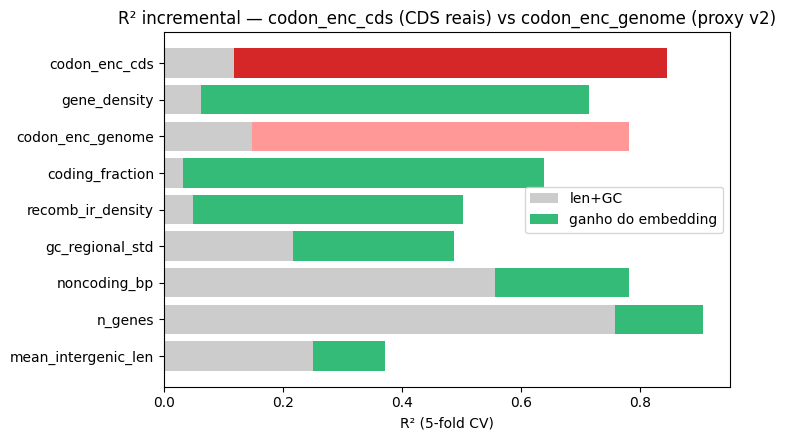

In [10]:
# Visualiza R² incremental — destaque para a correção do codon usage
import matplotlib.pyplot as plt
order = res.sort_values("R2_incremental")
fig,ax=plt.subplots(figsize=(7.5,4.5))
colors = ["#d62728" if f=="codon_enc_cds" else ("#ff9896" if f=="codon_enc_genome" else "#3b7") for f in order["feature"]]
ax.barh(order["feature"], order["R2_lenGC"], color="#ccc", label="len+GC")
ax.barh(order["feature"], order["R2_incremental"], left=order["R2_lenGC"], color=colors, label="ganho do embedding")
ax.set_xlabel("R² (5-fold CV)"); ax.set_title("R² incremental — codon_enc_cds (CDS reais) vs codon_enc_genome (proxy v2)")
ax.legend(); plt.tight_layout(); plt.show()

## Interpretação

- **`codon_enc_cds`** = viés de uso de códon medido sobre as **CDS reais** (gbff: join/complement + `codon_start`), o número correto a reportar. **`codon_enc_genome`** é o proxy frame-0 do v2 — a diferença entre os dois `R²_incremental` mede o quanto a aproximação distorcia.
- Os demais alvos e os embeddings são idênticos ao v2 (cache reaproveitado); `host`/`família`/PCA não mudam.
- **Cobertura:** genomas ausentes do `viral.1.genomic.gbff.gz` (ou com < 30 códons) ficam mascarados na linha do `codon_enc_cds` — ver o `n` por feature na tabela. Se a cobertura for baixa, considerar baixar os demais `viral.N` do RefSeq.

**Artefatos:** embeddings reaproveitados de `experiments/embed_probes/embeddings/`; CDS-ENC cacheado em `experiments/embed_probes/features/codon_enc_cds.parquet`. Este vira o referencial de codon usage (CDS) para o ΔR² do fine-tuning.